# Workshop 07

Outline
1. Regularization
2. Gradient Descent
3. Hand-Written Digits with Convolutional Neural Networks 
4. Advanced Image Classification with Convolutional Neural Networks 


Source: Deep Learning With Python, Part 1 - Chapter 4

`Keras` is one of the most popular Deep Learning libraries. PyTorch, Tensorflow and Jax are the most used numerical platforms in Python to build Deep Learning algorithms but they can be quite complex and difficult to use.

Keras, by contrast is easy to use and is capable of running on top of multiple low-level tensor operation frameworks. The full documentation of the keras API can be found [here](https://keras.io/).
Note that scikit learn also features an MLP implementation. Yet, keras has advanced to be one of the most popular frameworks used in practice, which is why we focus on it in this tutorial.

We use Keras to command PyTorch, therefore we need to install both. PyTorch's installation method varies by platform and environment manager, all of the options are listed here: https://pytorch.org/get-started/locally/

If you use the provided `uv` specification, you can just recreate your environment.

In [1]:
# supress versioning warnings of keras
import warnings
warnings.filterwarnings('ignore')

# Because keras can work with multiple different backends, it is important to specify that we want to use PyTorch before importing keras for the first time:

import os
os.environ["KERAS_BACKEND"] = "torch"

## 1. Regularization

To prevent a model from learning misleading or irrelevant patterns found in the
training data, the best solution is to get more training data. However, this is in many times out of our control.

Another approach is called - by now you should know that - regularization. 

### 1.1. Reducing the network’s size

The simplest way to prevent overfitting is to reduce the size of the model: the number
of learnable parameters in the model (which is determined by the number of layers
and the number of units per layer).

Or put it this way: A network with more parameters can better memorize stuff...

In [2]:
# Unfortunately, there is no closed form solution which gives us the best network size...
# So, we need to try out different models (or use grid search)

In [4]:
# Original  Model 
from keras import models
from keras import layers
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [5]:
# Simpler Model 
from keras import models
from keras import layers
model = models.Sequential()
model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [6]:
# Bigger Model 
model = models.Sequential()
model.add(layers.Dense(512, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [7]:
#### You need to load data, compile the network and then train it (with validation/hold out set)
#### Then you plot the validation loss for all these combinations

<img src="res/img1.png"></img>

<img src="res/img2.png"></img>

In [8]:
# This shows us that the bigger model starts to overfit immediately..

Instead of manually searching for the best model architecture (i.e., hyperparameters) you can use a method called grid-search. However, we will not cover this in this lecture - but you can find a tutorial here:

https://machinelearningmastery.com/grid-search-hyperparameters-deep-learning-models-python-keras/


Basically, the author conceleates keras with scikit's grid search module. 

### 1.2. Adding weight regularization

1. L1 regularization
2. L2 regularization

#### 1.2.1 Adding L2 Regularization to the model

In [10]:
from keras import regularizers
model = models.Sequential()

# kernel_regularizer = regularizers.l2(0.001), add those weights to the loss with an alpha of 0.001
# you could use also: regularizers.l1(0.001) for L1 regularization
# Documentation: https://keras.io/api/layers/regularizers/
model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),activation='relu', input_shape=(10000,)))

model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))

model.add(layers.Dense(1, activation='sigmoid'))

<img src="res/img3.png"></img>

### 1.2.3 Adding Dropout 

Idea: Randomly drop out a number of (activation) nodes during training. 
    
**Assume**: [0.2, 0.5, 1.3, 0.8, 1.1] is the output of a layer (after activation function).

Dropout sets randomly some of these weights to 0. For example: [0, 0.5, 1.3, 0, 1.1]. 

The *dropout rate* is the fraction of features that are zeroed out (usually between 0.2 and 0.5)

In [11]:
# Example Code 
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))

# Pass dropout rate!!!
model.add(layers.Dropout(0.5))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

# Compile..
# Fit..
# Evaluate...
# Doc: https://keras.io/api/layers/regularization_layers/dropout/

<img src="res/img4.png"></img>

### To recap, these are the most common ways to prevent overfitting in neural networks:
1. Get more training data.
2. Reduce the capacity of the network.
3. Add weight regularization.
4. Add dropout.
5. Data Augmentation (for image classification tasks)

## 2 Gradient Descent 

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets 
from sklearn.metrics import mean_squared_error

housing_data = datasets.fetch_california_housing()

features = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
target = pd.DataFrame(housing_data.target, columns=['Target'])

df = features.join(target)

X = df.MedInc
Y = df.Target

In [13]:
X.values

array([8.3252, 8.3014, 7.2574, ..., 1.7   , 1.8672, 2.3886],
      shape=(20640,))

In [14]:
# y = mx+b
# MSE 1/N * sum( (y_i - (m * x_i +b))^2) <= Loss Function

def gradient_descent(X, y, lr=0.05, iterations=10):
    
    '''
    Gradient Descent for a single feature
    '''
    
    m, b = 0.2, 0.2 # initial random parameters
    log, mse = [], [] # lists to store learning process
    N = len(X) # number of samples
    
    # MSE = 1/N SUM (y_i - (m*x_i +b))^2 
    # MSE' w.r.t. m => 1/N * SUM(-2*x_i*(m*x_i+b))
    # MSE' w.r.t. b => 1/N * SUM(-2*(m*x_i+b))

    for _ in range(iterations):
                
        f = y - (m*X + b)
    
        # Updating m and b 
        m -= lr * (-2 * X.dot(f).sum() / N) 
        b -= lr * (-2 * f.sum() / N)
        
        log.append((m, b))
        mse.append(mean_squared_error(y, (m*X + b)))        
    
    return m, b, log, mse


In [15]:
m, b, log, mse = gradient_descent(X, Y, lr=0.01, iterations=1000)

In [16]:
(m, b)

(np.float64(0.41893244701097204), np.float64(0.4461294563725838))

In [17]:
# Analytical Solution (compaed to )
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(features["MedInc"].to_numpy().reshape(-1, 1), Y)

In [18]:
(reg.coef_, reg.intercept_)

(array([0.41793849]), np.float64(0.4508557670326787))

##### Stochastic Gradient Descent

In [19]:
def stochastic_gradient_descent(X, y, lr=0.05, iterations=10, batch_size=10):
        
    '''
    Stochastic Gradient Descent for a single feature
    '''
    
    m, b = 0.5, 0.5 # initial parameters
    log, mse = [], [] # lists to store learning process
    
    for _ in range(iterations):
        
        indexes = np.random.randint(0, len(X), batch_size) # random sample "batch_size" elements from training set
        
        Xs = np.take(X.values, indexes)
        ys = np.take(y.values, indexes)
        N = len(Xs)
        
        f = ys - (m*Xs + b)
        
        # Updating parameters m and b
        m -= lr * (-2 * Xs.dot(f).sum() / N)
        b -= lr * (-2 * f.sum() / N)
        
        log.append((m, b))
        mse.append(mean_squared_error(y, m*X+b))        
    
    return m, b, log, mse

In [20]:
m, b, log, mse = stochastic_gradient_descent(X, Y, lr=0.01, iterations=100, batch_size = 100)

In [21]:
(m,b)

(np.float64(0.4106806365327238), np.float64(0.48297239129212))

## 2. Using CNNs to Classify Hand-written Digits on MNIST Dataset

<img src="res/img5.png"></img>

In [22]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D
from keras import utils

In [23]:
# Load Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [24]:
# Shape of data
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


In [25]:
# Flattening the images from the 28x28 pixels to 1D 784 pixels
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [26]:
# normalizing the data to help with the training
X_train /= 255
X_test /= 255

In [27]:
# To Categorical (One-Hot Encoding)
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = utils.to_categorical(y_train, n_classes)
Y_test = utils.to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (60000,)
Shape after one-hot encoding:  (60000, 10)


In [28]:
# Let's build again a very boring neural network
model = Sequential()
# hidden layer
model.add(Dense(100, input_shape=(784,), activation='relu'))
# output layer
model.add(Dense(10, activation='softmax'))

In [29]:
# looking at the model summary
model.summary()
# Compile
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
# Traing (####-> Caution, this is dedicated for validation data - I was just lazy...)
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8971 - loss: 0.3695 - val_accuracy: 0.9408 - val_loss: 0.2049
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9499 - loss: 0.1745 - val_accuracy: 0.9568 - val_loss: 0.1486
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9630 - loss: 0.1268 - val_accuracy: 0.9647 - val_loss: 0.1195
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9709 - loss: 0.1005 - val_accuracy: 0.9687 - val_loss: 0.1068
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9761 - loss: 0.0823 - val_accuracy: 0.9719 - val_loss: 0.0955
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9791 - loss: 0.0696 - val_accuracy: 0.9724 - val_loss: 0.0913
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9827 - loss: 0.0593 - val_accuracy: 0.9747 - val_loss: 0.0844
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9856 - loss: 0.0501 - val_accuracy: 0.

In [30]:
# new imports needed
from keras.layers import  Conv2D, MaxPool2D, Flatten

# And now with a convolutional neural network
# Doc: https://keras.io/api/layers/convolution_layers/

# Load again data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# DONT Vectorize - keep grid structure
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# normalize
X_train /= 255
X_test /= 255

# Sequential Model
model = Sequential()
# Convolutional layer

# 2D convolutional data 
# filters: number of kernels
# kernel size: (3, 3) pixel filter
# stride: (move one to the right, one to the bottom when you reach the end of the row)
# padding: "valid" => no padding => feature map is reduced
model.add(Conv2D(filters=25, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu', input_shape=(28,28,1)))


model.add(MaxPool2D(pool_size=(1,1)))
# flatten output such that the "densly" connected network can be attached
model.add(Flatten())

# hidden layer
model.add(Dense(100, activation='relu'))

# output layer
model.add(Dense(10, activation='softmax'))

# looking at the model summary
model.summary()

# compiling the sequential model
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# training the model for 10 epochs
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 25)     │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16900)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │     1,690,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,691,360 (6.45 MB)

 Trainable params: 1,691,360 (6.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9415 - loss: 0.1987 - val_accuracy: 0.9746 - val_loss: 0.0805
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9820 - loss: 0.0602 - val_accuracy: 0.9781 - val_loss: 0.0698
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9887 - loss: 0.0374 - val_accuracy: 0.9802 - val_loss: 0.0579
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9928 - loss: 0.0239 - val_accuracy: 0.9824 - val_loss: 0.0530
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9953 - loss: 0.0163 - val_accuracy: 0.9829 - val_loss: 0.0567
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9850 - val_loss: 0.0505
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9977 - loss: 0.0077 - val_accuracy: 0.9832 - val_loss: 0.0597
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9979 - loss: 0.0075 - va

## 3. Advanced Image Classification with Deep Convolutional Neural Networks
Dataset Description: https://keras.io/api/datasets/cifar10/

<img src="res/img6.png">

In [31]:
# Imports
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from keras import utils

# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# # Keep Grid Structure with 32x32 pixels (times 3; due to color channels)
X_train = X_train.reshape(X_train.shape[0], 32, 32, 3)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 3)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalize
X_train /= 255
X_test /= 255

# One-Hot Encoding
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = utils.to_categorical(y_train, n_classes)
Y_test = utils.to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Shape before one-hot encoding:  (50000, 1)
Shape after one-hot encoding:  (50000, 10)


In [32]:
# Create Model Object
model = Sequential()

# Add Conv. Layer
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 3)))

## What happens here?

# Stack 2. Conv. Layer
model.add(Conv2D(75, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# Stack 3. Conv. Layer
model.add(Conv2D(125, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten Output of Conv. Part such that we can add a densly connected network
model.add(Flatten()) 

# Add Hidden Layer and Dropout Reg.
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(250, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

# looking at the model summary
model.summary()

# Compile
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# Train
model.fit(X_train, Y_train, batch_size=128, epochs=2, validation_data=(X_test, Y_test))

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 75)     │        33,825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 125)    │        84,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 500)            │     4,000,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,247,985 (16.20 MB)

 Trainable params: 4,247,985 (16.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 92ms/step - accuracy: 0.4199 - loss: 1.5774 - val_accuracy: 0.5933 - val_loss: 1.1398
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.6159 - loss: 1.0886 - val_accuracy: 0.6830 - val_loss: 0.9079


Class: [3]


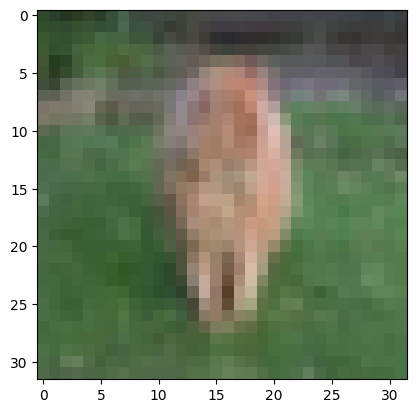

In [33]:
# rnd_img = np.random.randint(X_train.shape[0]-1)
rnd_img = 23935 # example
plt.imshow(X_train[rnd_img]) 
print(f'Class: {y_train[rnd_img]}')

In [34]:
print(f'Prediction: {model(X_train[rnd_img][None,...], training=False)}')
print(f'Class {model(X_train[rnd_img][None,...], training=False).argmax()}')

Prediction: tensor([[4.2707e-04, 1.3742e-04, 1.0843e-01, 7.7027e-02, 5.6849e-01, 1.4367e-01,
         7.8521e-02, 2.3123e-02, 8.5253e-05, 8.1488e-05]], device='mps:0',
       grad_fn=<SoftmaxBackward0>)
Class 4


Well, so the model thinks this is a deer (class 4) when it really is a cat (class 3)...
Why could that be the case? Let's look at an example image from class 4:

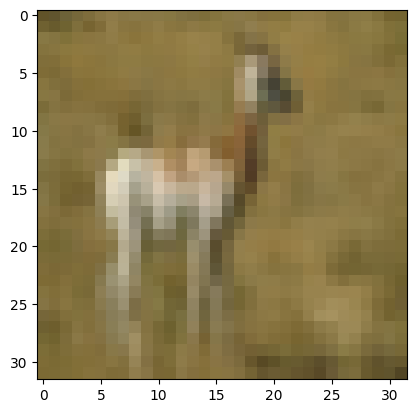

In [35]:
y_train[58]
plt.imshow(X_train[58]) 

I'll let you be the judge ;) 

## Task: Do it better ;) 

Let's have a look at the RGB channels

In [30]:
print(f'Deer: R channel avg: {X_train[58,:,:,0].mean()}')
print(f'Deer: G channel avg: {X_train[58,:,:,1].mean()}')
print(f'Deer: B channel avg: {X_train[58,:,:,2].mean()}')
print(f'Cat: R channel avg: {X_train[rnd_img,:,:,0].mean()}')
print(f'Cat: G channel avg: {X_train[rnd_img,:,:,1].mean()}')
print(f'Cat: B channel avg: {X_train[rnd_img,:,:,2].mean()}')

Deer: R channel avg: 0.5328814387321472
Deer: G channel avg: 0.4641084671020508
Deer: B channel avg: 0.2778722643852234
Cat: R channel avg: 0.3729473054409027
Cat: G channel avg: 0.43090152740478516
Cat: B channel avg: 0.3188304305076599


The G channel seems to be a problem as it is very close on average...

Maybe we could try greyscale to eliminate that...

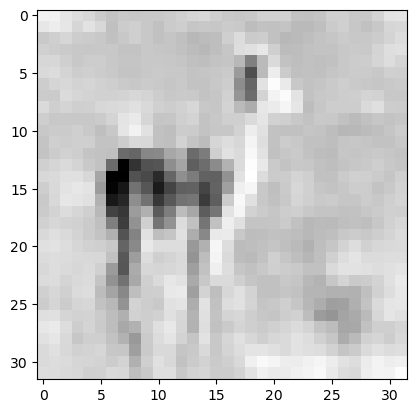

In [23]:
plt.imshow(X_train[58].mean(axis=2), cmap='Greys')

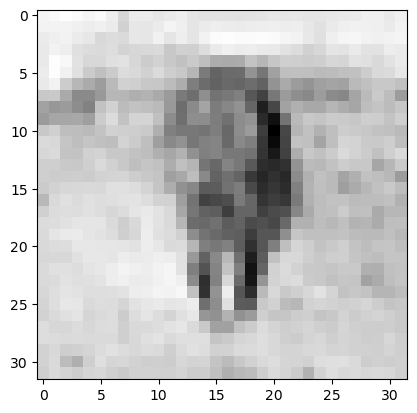

In [24]:
plt.imshow(X_train[rnd_img].mean(axis=2), cmap='Greys')

In [31]:
from keras.ops.image import rgb_to_grayscale

In [35]:
X_train_grey = rgb_to_grayscale(X_train, data_format='channels_last')
X_test_grey = rgb_to_grayscale(X_test, data_format='channels_last')

In [36]:
X_train_grey.shape

torch.Size([50000, 32, 32, 1])

Seems like it worked judging from the dimensions, let's try again with the exactly same setup:

In [37]:
# Create Model Object
model = Sequential()

# Add Conv. Layer
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 1)))

## What happens here?

# Stack 2. Conv. Layer
model.add(Conv2D(75, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# Stack 3. Conv. Layer
model.add(Conv2D(125, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten Output of Conv. Part such that we can add a densly connected network
model.add(Flatten()) 

# Add Hidden Layer and Dropout Reg.
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(250, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

# looking at the model summary
model.summary()

# Compile
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# Train
model.fit(X_train_grey, Y_train, batch_size=128, epochs=2, validation_data=(X_test_grey, Y_test))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 50)     │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 75)     │        33,825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 125)    │        84,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 500)            │     4,000,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,247,085 (16.20 MB)

 Trainable params: 4,247,085 (16.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 176ms/step - accuracy: 0.1656 - loss: 2.2120 - val_accuracy: 0.3102 - val_loss: 1.9069
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 173ms/step - accuracy: 0.3192 - loss: 1.8651 - val_accuracy: 0.4556 - val_loss: 1.5651


Hmm, this performs worse.
Does it actually, though? What this tells us that it is worse in terms of accuracy. Well, that was to be expected, because the previous network was pretty good at generalizing on colors probably, but this one now is working with less features (by the factor of 3) and still able to perform relatively well after just two episodes. We are probably able to to relatively good shape prediction with it after training for more episodes, whereas with the previous one, we would not be sure what it actually is predicting.